# Lab 3

## Ryan Waterman

## 9/20/2025

### Chapter 5 Exercise 1

Redefine the model to be w2 * t_u ** 2 + w1 * t_u + b.

### Setting Up the Initial Model

In [232]:
import numpy as np
import torch
torch.set_printoptions(edgeitems=2, linewidth=75)

In [233]:
t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

In [234]:
def model(t_u, w, b):
    return w * t_u + b

In [235]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

In [236]:
w = torch.ones(())
b = torch.zeros(())

t_p = model(t_u, w, b)
t_p

tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000,
        21.8000, 48.4000, 60.4000, 68.4000])

In [237]:
loss = loss_fn(t_p, t_c)
loss

tensor(1763.8848)

In [238]:
x = torch.ones(())
y = torch.ones(3,1)
z = torch.ones(1,3)
a = torch.ones(2, 1, 1)
print(f"shapes: x: {x.shape}, y: {y.shape}")
print(f"        z: {z.shape}, a: {a.shape}")
print("x * y:", (x * y).shape)
print("y * z:", (y * z).shape)
print("y * z * a:", (y * z * a).shape)

shapes: x: torch.Size([]), y: torch.Size([3, 1])
        z: torch.Size([1, 3]), a: torch.Size([2, 1, 1])
x * y: torch.Size([3, 1])
y * z: torch.Size([3, 3])
y * z * a: torch.Size([2, 3, 3])


In [239]:
delta = 0.1

loss_rate_of_change_w = \
    (loss_fn(model(t_u, w + delta, b), t_c) - 
     loss_fn(model(t_u, w - delta, b), t_c)) / (2.0 * delta)

In [240]:
learning_rate = 1e-2

w = w - learning_rate * loss_rate_of_change_w

In [241]:
loss_rate_of_change_b = \
    (loss_fn(model(t_u, w, b + delta), t_c) - 
     loss_fn(model(t_u, w, b - delta), t_c)) / (2.0 * delta)

b = b - learning_rate * loss_rate_of_change_b

In [242]:
def dloss_fn(t_p, t_c):
    dsq_diffs = 2 * (t_p - t_c) / t_p.size(0)  # <1>
    return dsq_diffs

In [243]:
def dmodel_dw(t_u, w, b):
    return t_u

In [244]:
def dmodel_db(t_u, w, b):
    return 1.0

In [245]:
def grad_fn(t_u, t_c, t_p, w, b):
    dloss_dtp = dloss_fn(t_p, t_c)
    dloss_dw = dloss_dtp * dmodel_dw(t_u, w, b)
    dloss_db = dloss_dtp * dmodel_db(t_u, w, b)
    return torch.stack([dloss_dw.sum(), dloss_db.sum()])

In [246]:
import matplotlib.pyplot as plt

def plot_loss(losses: list):
    x = np.array([i for i in range(1, len(losses)+1)])
    y = np.array(losses)

    plt.plot(x, y)

In [247]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c,
                  print_params=True):
    losses = []
    for epoch in range(1, n_epochs + 1):
        w, b = params

        t_p = model(t_u, w, b)  # <1>
        loss = loss_fn(t_p, t_c)
        grad = grad_fn(t_u, t_c, t_p, w, b)  # <2>

        losses.append(float(loss))

        params = params - learning_rate * grad

        if epoch in {1, 2, 3, 10, 11, 99, 100, 4000, 5000}:  # <3>
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
            if print_params:
                print('    Params:', params)
                print('    Grad:  ', grad)
        if epoch in {4, 12, 101}:
            print('...')

        if not torch.isfinite(loss).all():
            break  # <3>
            
    return params, losses

Epoch 1, Loss 1763.884766
Epoch 2, Loss 5802484.500000
Epoch 3, Loss 19408029696.000000
...
Epoch 10, Loss 90901105189019073810297959556841472.000000
Epoch 11, Loss inf


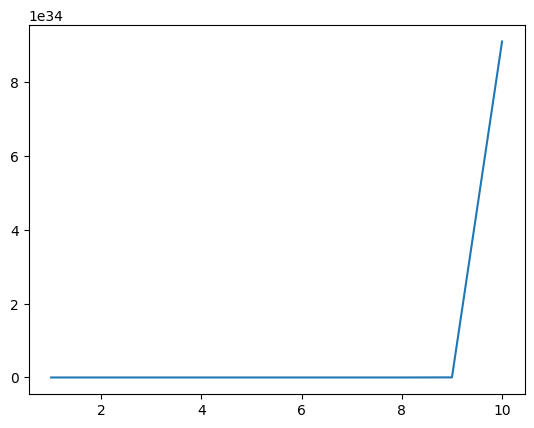

In [248]:
params, losses = training_loop(
    n_epochs = 100, 
    learning_rate = 1e-2, 
    params = torch.tensor([1.0, 0.0]), 
    t_u = t_u, 
    t_c = t_c,
    print_params=False)

plot_loss(losses)

Epoch 1, Loss 1763.884766
Epoch 2, Loss 323.090515
Epoch 3, Loss 78.929634
...
Epoch 10, Loss 29.105247
Epoch 11, Loss 29.104168
...
Epoch 99, Loss 29.023582
Epoch 100, Loss 29.022667


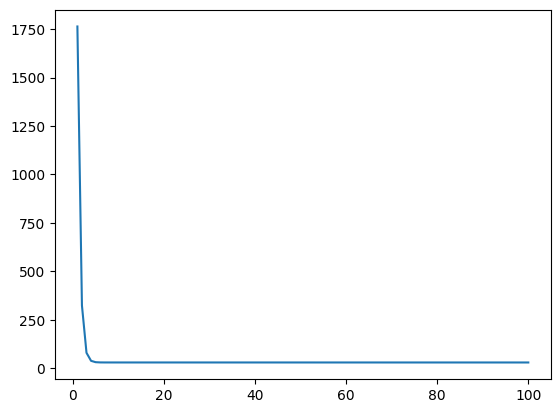

In [249]:
params, losses = training_loop(
    n_epochs = 100, 
    learning_rate = 1e-4, 
    params = torch.tensor([1.0, 0.0]), 
    t_u = t_u, 
    t_c = t_c,
    print_params=False)

plot_loss(losses)

In [250]:
t_un = 0.1 * t_u

Epoch 1, Loss 80.364342
Epoch 2, Loss 37.574913
Epoch 3, Loss 30.871077
...
Epoch 10, Loss 29.030489
Epoch 11, Loss 28.941877
...
Epoch 99, Loss 22.214186
Epoch 100, Loss 22.148710


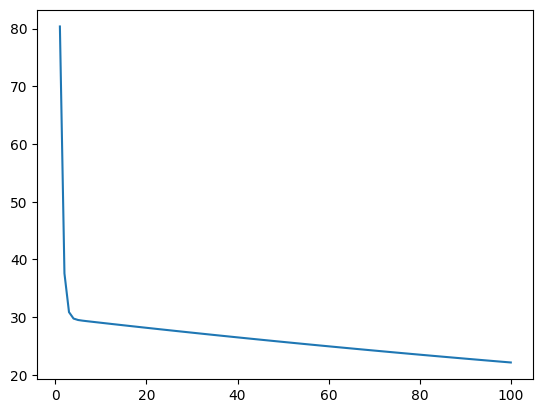

In [251]:
params, losses = training_loop(
    n_epochs = 100, 
    learning_rate = 1e-2, 
    params = torch.tensor([1.0, 0.0]), 
    t_u = t_un, # <1>
    t_c = t_c,
    print_params=False)

plot_loss(losses)

Epoch 1, Loss 80.364342
Epoch 2, Loss 37.574913
Epoch 3, Loss 30.871077
...
Epoch 10, Loss 29.030489
Epoch 11, Loss 28.941877
...
Epoch 99, Loss 22.214186
Epoch 100, Loss 22.148710
...
Epoch 4000, Loss 2.927680
Epoch 5000, Loss 2.927648


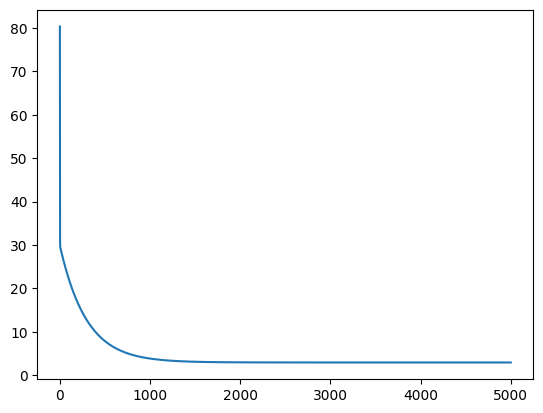

In [252]:
params, losses = training_loop(
    n_epochs = 5000, 
    learning_rate = 1e-2, 
    params = torch.tensor([1.0, 0.0]), 
    t_u = t_un, 
    t_c = t_c,
    print_params = False)

plot_loss(losses)

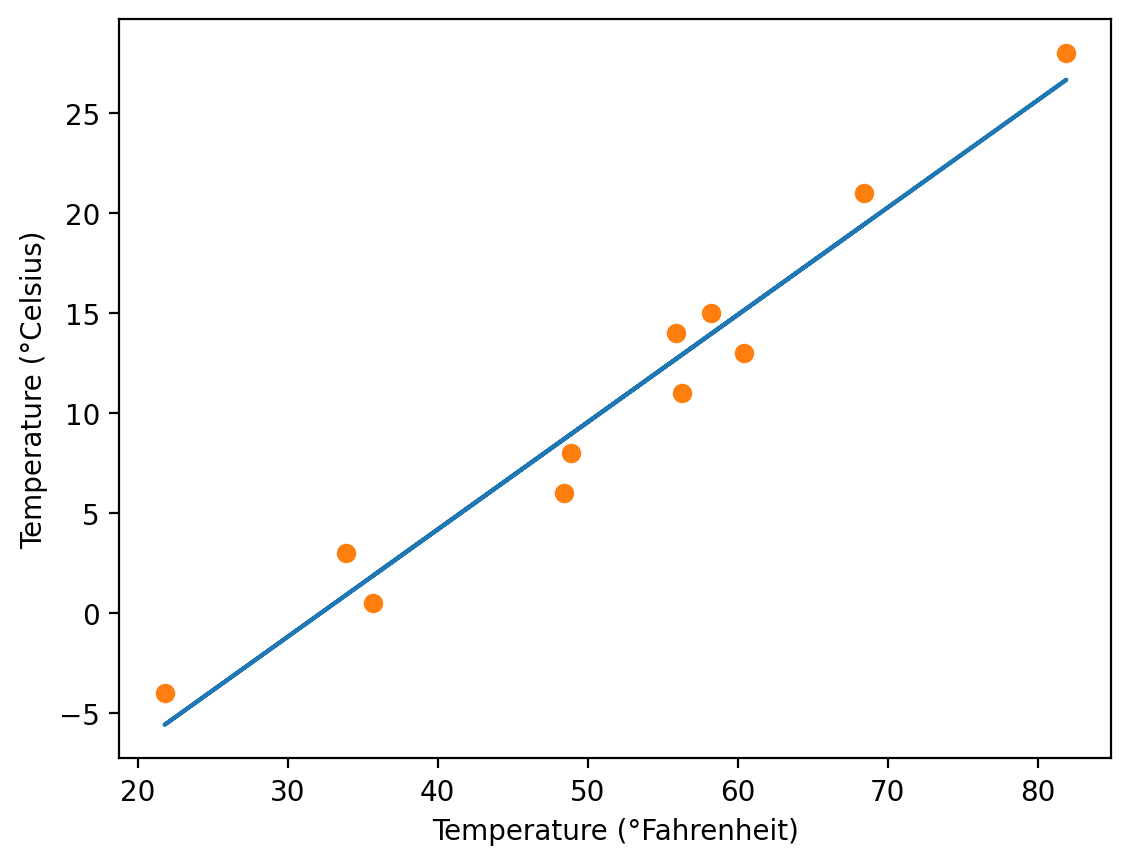

In [253]:
%matplotlib inline
from matplotlib import pyplot as plt

t_p = model(t_un, *params)  # <1>

fig = plt.figure(dpi=200)
plt.xlabel("Temperature (°Fahrenheit)")
plt.ylabel("Temperature (°Celsius)")
plt.plot(t_u.numpy(), t_p.detach().numpy()) # <2>
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.savefig("temp_unknown_plot.png", format="png")  # bookskip

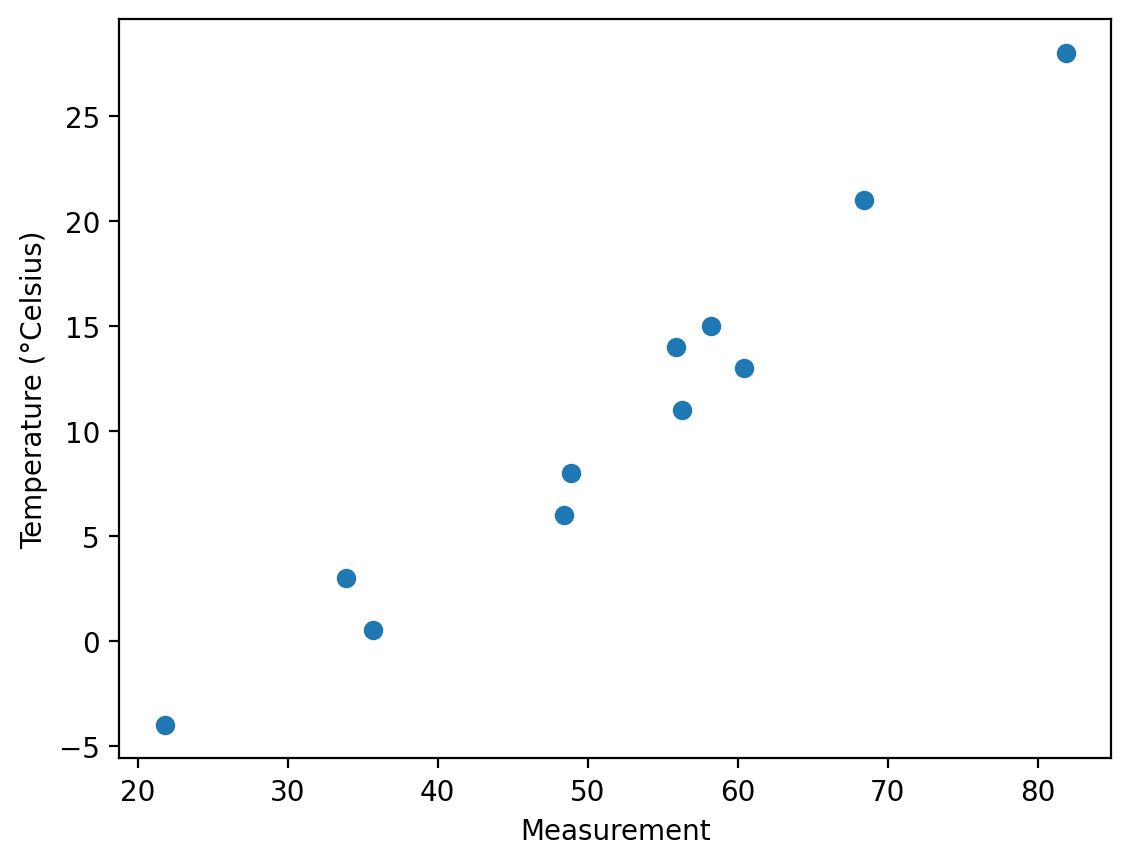

In [254]:
%matplotlib inline
from matplotlib import pyplot as plt

fig = plt.figure(dpi=200)
plt.xlabel("Measurement")
plt.ylabel("Temperature (°Celsius)")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')

plt.savefig("temp_data_plot.png", format="png")

### Part A

What parts of the training loop, and so on, need to change to accommodate this redefinition?

#### First, set up the new model.

In [255]:
def new_model(t_u, w2, w1, b):
    return w2 * t_u ** 2 + w1 * t_u + b

#### Now, step through the example and identify items that must change to accomodate the new model.

#### Loss Function:

In [256]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return torch.tensor([squared_diffs.mean()])

**The loss function does not need to change. It takes in the initial data tensor and the model output, then compares them with a squared difference.**

#### Derivative of the Loss Function:

In [257]:
def dloss_fn(t_p, t_c):
    dsq_diffs = 2 * (t_p - t_c) / t_p.size(0)  # <1>
    return dsq_diffs

**The derivative of the loss function does not need to change as it, again, only compares the model output to the initial data.**

#### Derivative of the model with respect to w1 and w2:

In [258]:
def dmodel_dw(t_u, w2, w1, b):
    dm_w2 = t_u**2
    dm_w1 = t_u
    return torch.stack([dm_w2, dm_w1])

**This requires the partial derivative of each weight in the model. For an arbitrarily large number of nodes, n, in a single layer model (like this), the output will be a tensor of size n. Each element in this tensor will be the partial derivative of the model with respect the corresponding weight of the node.**

**The model is represented by the equation:**
     
**w2 * t_u ** 2 + w1 * t_u + b**

**therefore the partial derivative of the model with respect to w2 is:**

**t_u ** 2 + 0 + 0**

**and the partial derivative of the model with respect to w1 is:**

**0 + t_u + 0**

**resulting in an output set of parameters:**

**[t_u ** 2, t_u]**

#### Derivative of the model with respect to b:

In [259]:
def dmodel_db(t_u, w2, w1, b):
    return 1.0

**The derivative of the model with respect to b is unchanged.**

#### Gradient Function:

In [260]:
def grad_fn(t_u, t_c, t_p, w2, w1, b):
    dloss_dtp = dloss_fn(t_p, t_c)
    # Compute the derivative of the loss for each weight 
    for i, dweight in enumerate(dmodel_dw(t_u, w2, w1, b)):
        if not i:
            dloss_dw = torch.sum(dloss_dtp * dweight)
        else: 
            dloss_dw = torch.stack([dloss_dw, torch.sum(dloss_dtp * dweight)])
    dloss_db = dloss_dtp * dmodel_db(t_u, w2, w1, b)
    return torch.cat([dloss_dw, dloss_db.sum().unsqueeze(0)])

**The gradient function has been modified to take the additional weight as a parameter, which is then passed to the modified derivative functions. There was additional logic added to handle any number of input weights, although the derivative functions currently only support w1 and w2.**

#### Training Loop:

In [261]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c,
                  print_params=True):
    losses = []
    for epoch in range(1, n_epochs + 1):
        w2, w1, b = params

        t_p = new_model(t_u, w2, w1, b)  # <1>
        loss = loss_fn(t_p, t_c)
        grad = grad_fn(t_u, t_c, t_p, w2, w1, b)  # <2>
        losses.append(float(loss))

        params = params - learning_rate * grad

        if epoch in {1, 2, 3, 10, 11, 99, 100, 4000, 5000, 10000, 20000, 100000}:  # <3>
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
            if print_params:
                print('    Params:', params)
                print('    Grad:  ', grad)
        if epoch in {4, 12, 101}:
            print('...')

        if not torch.isfinite(loss).all():
            break  # <3>
            
    return params, losses

**The training loop now takes in the new model and expands the parameters to w1 and w2.**

### Part B

What parts are agnostic to swapping out the model?

**As decribed in part A, the loss function, derivative of the loss function, and derivative of the model with respect to the bias value are unchanged.**

### Part C

Is the resulting loss higher or lower after training?

In [262]:
params, losses = training_loop(
    n_epochs = 5000, 
    learning_rate = 5e-4, 
    params = torch.tensor([1.0, 1.0, 0.0]), 
    t_u = t_un, 
    t_c = t_c,
    print_params = True)


Epoch 1, Loss 675.794373
    Params: tensor([ 0.1302,  0.8602, -0.0241])
    Grad:   tensor([1739.5315,  279.6790,   48.1760])
Epoch 2, Loss 33.342464
    Params: tensor([ 0.2813,  0.8799, -0.0218])
    Grad:   tensor([-302.0496,  -39.5566,   -4.4771])
Epoch 3, Loss 14.127408
    Params: tensor([ 0.2559,  0.8721, -0.0242])
    Grad:   tensor([50.7241, 15.5900,  4.6150])
...
Epoch 10, Loss 13.301749
    Params: tensor([ 0.2641,  0.8468, -0.0354])
    Grad:   tensor([-1.2367,  7.3733,  3.2389])
Epoch 11, Loss 13.268586
    Params: tensor([ 0.2647,  0.8431, -0.0371])
    Grad:   tensor([-1.2343,  7.3606,  3.2338])
...
Epoch 99, Loss 10.750979
    Params: tensor([ 0.3151,  0.5430, -0.1699])
    Grad:   tensor([-1.0610,  6.3212,  2.8197])
Epoch 100, Loss 10.726483
    Params: tensor([ 0.3156,  0.5398, -0.1713])
    Grad:   tensor([-1.0593,  6.3103,  2.8153])
...
Epoch 4000, Loss 3.417055
    Params: tensor([ 0.6107, -1.1422, -1.4167])
    Grad:   tensor([ 0.0075, -0.0892,  0.2521])
Epoch 50

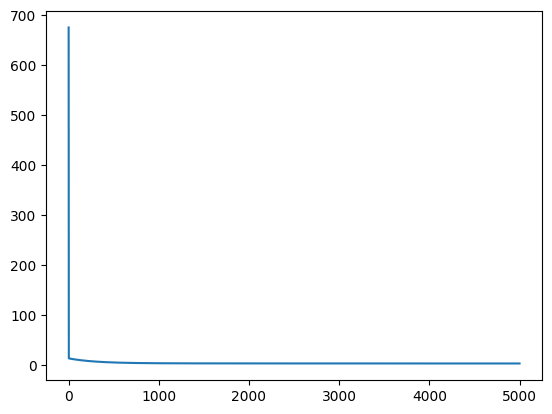

In [263]:
plot_loss(losses)

**The loss is lower after training, reaching 3.38 in this case.**

### Part D

Is the actual result better or worse?

**Based on the loss, the result of this model was worse than that of the original model. The loss for the original model with 5000 epochs reached 2.92, where the new model only reached 3.38. Interestingly, the new model converged faster than the original, even with a much smaller learning rate. I believe this is a function of w2 being exponentially related to the data. Any learning rate higher than 5e-4 would not converge and the loss would go to infinity.**

### This was fun and informative... Now I want to experiment with making framework for an arbitrarily large model.

In [264]:
class Model():
    def __init__(self, t_u, t_c, n_weights):
        self.t_u = self.normalize(t_u)
        self.t_c = t_c
        self.n_weights = n_weights
        self.create_model()

    def normalize(self, t_u):
        return (t_u - t_u.mean()) / t_u.std() #Normalize to stop loss explosion

    def create_model(self):
        """
        Create a model with randomly initialized weights.
        """
        torch.manual_seed(2)
        self.weights = torch.rand(self.n_weights)
        self.b = torch.rand(1).item()
        self.t_p = torch.zeros(len(self.t_u))

        for i in range(0, len(self.weights)):
            self.t_p += self.weights[i]*self.t_u

        self.t_p += self.b

    def update_model(self):
        predictions = torch.zeros(len(self.t_u))
        for i in range(0, len(self.weights)):
            predictions += self.weights[i]*self.t_u
        self.t_p = predictions + self.b

    def loss_fn(self):
        squared_diffs = (self.t_p - self.t_c)**2
        return torch.tensor([squared_diffs.mean()])
    
    def dloss_fn(self):
        dsq_diffs = 2 * (self.t_p - self.t_c) / self.t_p.size(0)  # <1>
        return dsq_diffs
    
    def dmodel_dw(self):
        # Compute the derivative of the loss for each weight 
        for i in range(len(self.weights)):
            if not i:
                dm_dw = self.t_u.unsqueeze(0).unsqueeze(0)
            else: 
                dm_dw = torch.cat([dm_dw, self.t_u.unsqueeze(0).unsqueeze(0)], dim=0)
        return dm_dw
    
    def dmodel_db(self):
        return 1.0

    def grad_fn(self):
        dloss_dtp = self.dloss_fn()
        # Compute the derivative of the loss for each weight 
        for i, dweight in enumerate(self.dmodel_dw()):
            if not i:
                dloss_dw = torch.sum(dloss_dtp * dweight).unsqueeze(0)
            else: 
                dloss_dw = torch.cat([dloss_dw, torch.sum(dloss_dtp * dweight).unsqueeze(0)])
        dloss_db = dloss_dtp * self.dmodel_db()
        return dloss_dw, dloss_db.sum()
    
    def train(self, n_epochs, learning_rate, print_params=True):
        self.losses = []
        for epoch in range(1, n_epochs + 1):

            self.update_model()
            loss = self.loss_fn()
            dloss_dw, dloss_db = self.grad_fn()  # <2>
            self.losses.append(float(loss))

            self.weights = self.weights - learning_rate * dloss_dw
            self.b = self.b - learning_rate * dloss_db

            if epoch in list(range(0, n_epochs+1, int(n_epochs/10))):  # <3>
                print('Epoch %d, Loss %f' % (epoch, float(loss)))
                if print_params:
                    print('    Weights:', self.weights)
                    print('    Grad:  ', dloss_dw, dloss_db)

            if not torch.isfinite(loss).all():
                print("Model did not converge.")
                break  # <3>
    
    def plot_loss(self):
        x = np.array([i for i in range(1, len(self.losses)+1)])
        y = np.array(self.losses)

        plt.plot(x, y)

    def predict(self, data):
        data = self.normalize(data)
        predictions = torch.zeros(len(data))
        for i in range(0, len(self.weights)):
            predictions += self.weights[i]*data
        return predictions + self.b

    def plot_predictions(self, data, predictions):
        x = np.array(data)
        y = np.array(predictions)
        plt.plot(x, y)
        plt.plot(data.numpy(), self.t_c.numpy(), 'o')


In [265]:
model = Model(t_u, t_c, 5)
model.train(50000, 1e-4, print_params=False)

Epoch 5000, Loss 16.147488
Epoch 10000, Loss 4.715863
Epoch 15000, Loss 3.169613
Epoch 20000, Loss 2.960388
Epoch 25000, Loss 2.932080
Epoch 30000, Loss 2.928249
Epoch 35000, Loss 2.927730
Epoch 40000, Loss 2.927656
Epoch 45000, Loss 2.927651
Epoch 50000, Loss 2.927651


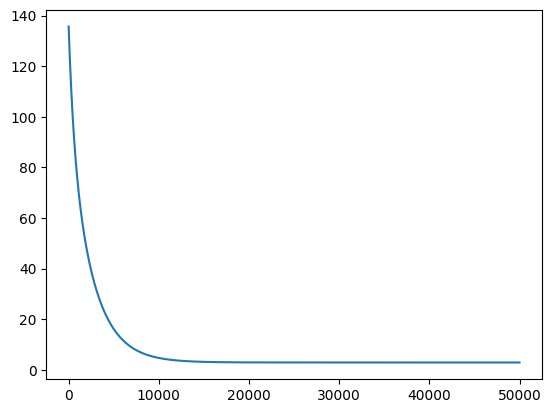

In [266]:
model.plot_loss()

In [267]:
predictions = model.predict(t_u)
predictions

tensor([ 1.8559, 12.6983, 13.9328, 26.6539, 12.9130,  8.9410,  0.8897,
        -5.6050,  8.6727, 15.1137, 19.4077])

C:\Users\water\AppData\Local\Temp\ipykernel_14112\2967054700.py:98: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  x = np.array(data)
C:\Users\water\AppData\Local\Temp\ipykernel_14112\2967054700.py:99: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  y = np.array(predictions)


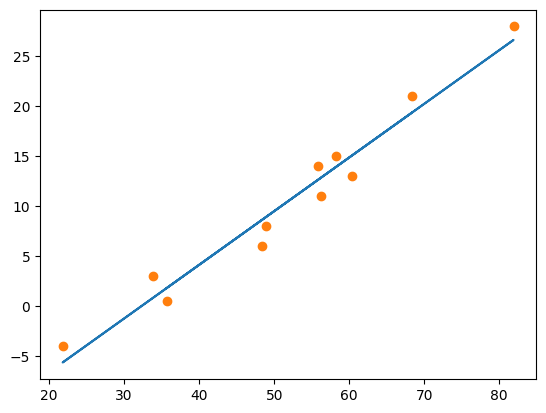

In [268]:
model.plot_predictions(t_u, predictions)

**Cool, this seems to work. Because this is a single layer model, it is essentially just a scaleable linear regression model. If I wanted to get an exact fit to the data, I would have to add another layer, whether it be another linear layer or an activation layer. Let's test with some other input parameters.**

In [269]:
model = Model(t_u, t_c, 20)
model.train(50000, 1e-4, print_params=False)

Epoch 5000, Loss 17.822226
Epoch 10000, Loss 4.943004
Epoch 15000, Loss 3.200339
Epoch 20000, Loss 2.964545
Epoch 25000, Loss 2.932642
Epoch 30000, Loss 2.928320
Epoch 35000, Loss 2.927741
Epoch 40000, Loss 2.927659
Epoch 45000, Loss 2.927651
Epoch 50000, Loss 2.927651


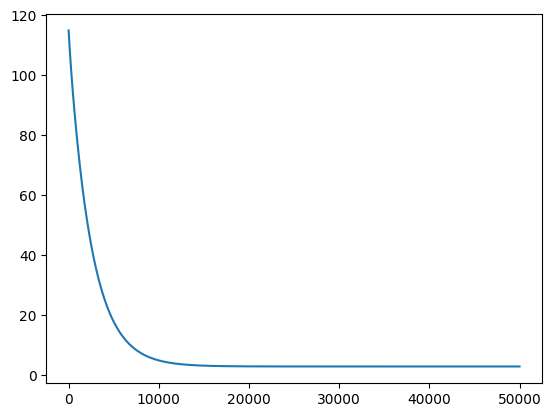

In [270]:
model.plot_loss()

In [271]:
predictions = model.predict(t_u)
predictions

tensor([ 1.8556, 12.6984, 13.9330, 26.6545, 12.9131,  8.9410,  0.8894,
        -5.6056,  8.6726, 15.1139, 19.4080])

C:\Users\water\AppData\Local\Temp\ipykernel_14112\2967054700.py:98: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  x = np.array(data)
C:\Users\water\AppData\Local\Temp\ipykernel_14112\2967054700.py:99: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  y = np.array(predictions)


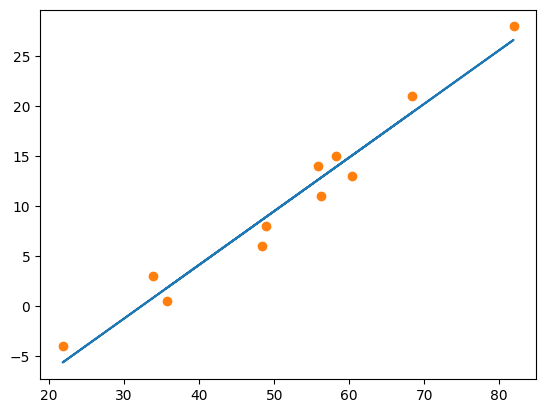

In [272]:
model.plot_predictions(t_u, predictions)

**I think I want to attempt creating a multi-layer model... I might give up though. I never thought I'd be doing this kind of thing for fun at 9 am on a Sunday :)**

In [273]:
class MultiLayerModel():
    def __init__(self, t_u, t_c, n_hidden):
        self.t_u = self.normalize(t_u)
        self.t_c = t_c
        self.n_hidden = n_hidden
        self.create_model()

    def normalize(self, t_u):
        return (t_u - t_u.mean()) / t_u.std() #Normalize to stop loss explosion

    def create_model(self):
        """
        Create a two-layer model.
        Layer 1 (Input -> Hidden) and Layer 2 (Hidden -> Output)
        """
        torch.manual_seed(42)
        # <--- NEW: Weights and biases for two layers
        # Layer 1: 1 input feature -> n_hidden neurons
        self.w1 = torch.randn(self.n_hidden, 1)
        self.b1 = torch.randn(self.n_hidden)
        # Layer 2: n_hidden neurons -> 1 output feature
        self.w2 = torch.randn(1, self.n_hidden)
        self.b2 = torch.randn(1)

    def update_model(self):
        """
        Perform a forward pass through the network.
        """
    
        hidden_linear = self.w1 @ self.t_u.unsqueeze(0) + self.b1.unsqueeze(1)

        # Apply the non-linear activation function (tanh)
        # courtesy of Gemini
        hidden_activated = torch.tanh(hidden_linear)

        output = self.w2 @ hidden_activated + self.b2

        self.hidden_activated = hidden_activated
        self.t_p = output.squeeze(0) # Final prediction

    def loss_fn(self):
        squared_diffs = (self.t_p - self.t_c)**2
        return squared_diffs.mean()

    def dloss_fn(self):
        # Derivative of the loss with respect to the prediction (t_p)
        dsq_diffs = 2 * (self.t_p - self.t_c) / self.t_p.size(0)
        return dsq_diffs

    def grad_fn(self):
        """
        Perform backpropagation to get gradients for all weights and biases.

        Gemini helped a lot with this one... it even threw in an activation function for me. 
        What a kind AI. 
        """
        # <--- NEW: Backpropagation logic using the chain rule
        dloss_dtp = self.dloss_fn()

        # --- Gradients for Layer 2 (w2, b2) ---
        # d(loss)/d(w2) = d(loss)/d(t_p) * d(t_p)/d(w2)
        # d(t_p)/d(w2) is the input to layer 2, which is `self.hidden_activated`
        dloss_dw2 = dloss_dtp @ self.hidden_activated.t()

        # d(loss)/d(b2) = d(loss)/d(t_p) * d(t_p)/d(b2)
        dloss_db2 = dloss_dtp.sum()

        # --- Gradients for Layer 1 (w1, b1) ---
        # We need to backpropagate the gradient from the output layer to the hidden layer
        # d(loss)/d(hidden_activated) = d(loss)/d(t_p) * d(t_p)/d(hidden_activated)
        # d(t_p)/d(hidden_activated) is w2
        dloss_dhidden_activated = self.w2.t() @ dloss_dtp.unsqueeze(0)

        # Now, backpropagate through the tanh activation function
        # The derivative of tanh(x) is 1 - tanh(x)^2
        dtanh = 1 - self.hidden_activated**2
        dloss_dhidden_linear = dloss_dhidden_activated * dtanh

        # Finally, get gradients for w1 and b1
        # d(loss)/d(w1) = d(loss)/d(hidden_linear) * d(hidden_linear)/d(w1)
        # d(hidden_linear)/d(w1) is the input to the whole model, `self.t_u`
        dloss_dw1 = dloss_dhidden_linear @ self.t_u.unsqueeze(1)
        dloss_db1 = dloss_dhidden_linear.sum(dim=1)

        return dloss_dw1, dloss_db1, dloss_dw2, dloss_db2

    def train(self, n_epochs, learning_rate, print_params=True):
        self.losses = []
        for epoch in range(1, n_epochs + 1):
            self.update_model()
            loss = self.loss_fn()
            dloss_dw1, dloss_db1, dloss_dw2, dloss_db2 = self.grad_fn()

            # Stop training if the loss goes to 0
            if round(loss.item(), (7)) == 0:
                print("Loss has reached 0. Stopping training.")
                break
            
            self.losses.append(float(loss))

            # <--- NEW: Update all four parameters
            self.w1 = self.w1 - learning_rate * dloss_dw1
            self.b1 = self.b1 - learning_rate * dloss_db1
            self.w2 = self.w2 - learning_rate * dloss_dw2
            self.b2 = self.b2 - learning_rate * dloss_db2

            if epoch % (n_epochs // 10) == 0:
                print('Epoch %d, Loss %f' % (epoch, float(loss)))

        print('Final Loss: %f' % float(loss))

    def plot_loss(self):
        x = np.array([i for i in range(1, len(self.losses)+1)])
        y = np.array(self.losses)
        plt.plot(x, y)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Over Time")
        plt.show()

    def predict(self, data):
        """
        This is just the update function with input data.
        """

        data = self.normalize(data)

        hidden_linear = self.w1 @ data.unsqueeze(0) + self.b1.unsqueeze(1)

        hidden_activated = torch.tanh(hidden_linear)

        output = self.w2 @ hidden_activated + self.b2

        self.hidden_activated = hidden_activated

        return output.squeeze(0) # Final prediction

    def plot_predictions(self, data, predictions):
        plt.plot(data.numpy(), predictions.numpy(), 'o')
        plt.plot(data.numpy(), self.t_c.numpy(), 'o')

Epoch 50000, Loss 0.492882
Epoch 100000, Loss 0.034501
Epoch 150000, Loss 0.000066
Epoch 200000, Loss 0.000007
Epoch 250000, Loss 0.000000
Loss has reached 0. Stopping training.
Final Loss: 0.000000


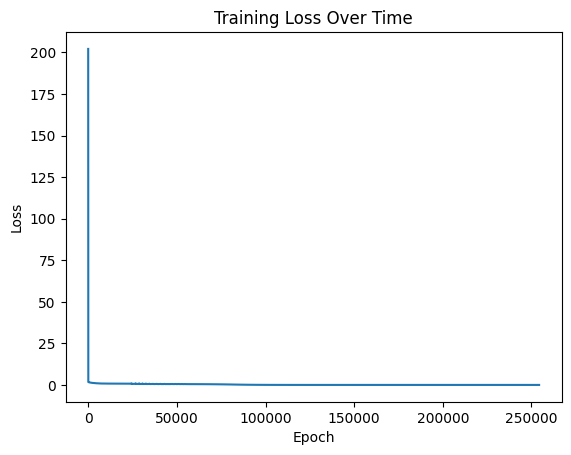

In [274]:
# Instantiate the model with 10 hidden neurons
model = MultiLayerModel(t_u, t_c, n_hidden=100)

# Train for more epochs with a smaller learning rate
model.train(n_epochs=500000, learning_rate=2e-2)

# Plot the results
model.plot_loss()

In [275]:
predictions = model.predict(t_u)
predictions

tensor([ 0.4999, 13.9996, 14.9996, 27.9999, 10.9996,  7.9998,  2.9999,
        -4.0001,  5.9998, 12.9998, 20.9999])

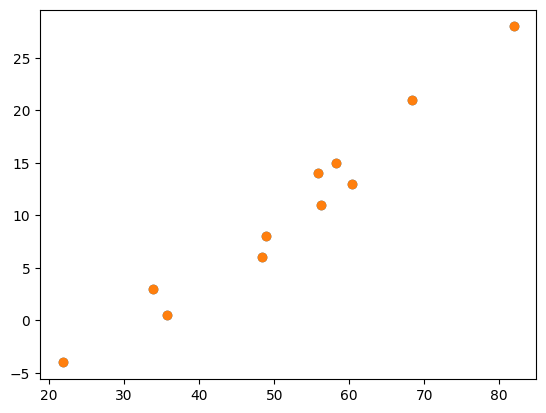

In [276]:
model.plot_predictions(t_u, predictions)

**Awesome, I've managed to overfit the model to perfectly predict the input data. I think I am satisfied now.**